# STRATA — Marco práctico: ¿aporta valor supervisar estadísticamente a un agente LLM de trading?

**Notebook DEFINITIVO y canónico del TFG** (Raquel García, Matemáticas y Ciencia de Datos, UCM).

**Tesis.** Un agente LLM de trading (AI Hedge Fund, 5 personalidades) puede perder dinero y acertar la dirección
< 50 %. La pregunta no es *"¿la IA acierta?"* sino *"¿una capa de supervisión estadística clásica (STRATA:
régimen, cambio de opinión, volatilidad) **rescata** a ese agente, y puede **probarse**?"*. Se defiende como un
quant ante un comité: se **vende** con el caso SPY, pero se **prueba** con lo que sobrevive a un test, y **cada
decisión va justificada con su material** (tabla/figura/cita).

**Dos supervisores (el eje del capítulo).** STRATA ofrece una **regla transparente** (M8, canal régimen) y un
**aprendiz flexible** (M10 XGBoost / AutoML-H2O, canal ML). Cuál rescata **depende de la naturaleza del activo**;
lo demostramos (§5) y lo confirmamos con clustering (§6).

**Honestidad (la lleva el cuaderno, no la esconde).** Batir al baseline trivial (ZeroR / B&H) en accuracy es
**nominal** (n≈250 → ventana corta). STRATA **no genera alfa**: rescata al perdedor y delimita dónde funciona.

Estrategias: **M5** agente · **M8** STRATA-regla (override-C) · **M10** meta-learner XGBoost · **AutoML** (H2O) ·
**ZeroR** clase mayoritaria · **B&H** comprar-y-mantener.

## Objetivos (cada uno con su validación)

| | Objetivo | Validación |
|---|---|---|
| **O1** | El agente solo (M5) pierde y acierta < 0.5 | sign test vs 0.5; Sharpe negativo (§3) |
| **O2** | STRATA **rescata** al agente | McNemar M8/M10/AutoML vs M5 (§3,§4); ΔSharpe/ΔmaxDD bootstrap pooled (§4) |
| **O3** | Un ML potente **redescubre** STRATA | cuota SHAP por bloque + permutation; ablación (§3,§4) |
| **O4** | **Mecanismo**: por qué gana cada canal | crisis_mean + intervención/acierto de M8 por activo (§5) |
| **O5** | **Patrón**: la naturaleza del activo causa el resultado | clustering + tabla cruzada cluster×canal (§6) |
| **O6** | **Honestidad y límite** | techo ZeroR; apéndice de los 5 donde STRATA no aporta (§7,§8) |
| **O7** | **Rigor** | test+IC+cita; `signal_lag=1`; embargo=1; sin KFold; ex-ante (§1,§2) |

## Notación
| Símbolo | Significado |
|---|---|
| $r_t$, $r_{t+1}$ | log-retorno de hoy / del día siguiente (lo que captura la posición de hoy) |
| $y_t=\mathbb{1}[r_{t+1}>0]$ | etiqueta direccional (horizonte 1) |
| $s_t\in\{$Calma,Estrés,Crisis$\}$ | régimen oculto (HMM K=3); $\gamma_{t,k}=P(s_t{=}k\mid\mathcal F_t)$ filtrado |
| $\sigma_t$ | volatilidad GARCH(1,1)-t (prevista antes de ver $r_t$) |
| $w_t\in\{-1,0,1\}$ | posición; P&L con `signal_lag=1`: $w_t\,r_{t+1}$ |

## Mapa del capítulo
§1 datos/protocolo → §2 mecánica ex-ante → §3 caso SPY → §4 panel de 10 → §5 **mecanismo por activo** →
§6 **clustering (naturaleza→resultado)** → §7 robustez/honestidad → §8 apéndice (los 5) → §9 conclusiones.

In [1]:
# --- Bootstrap raíz + carga de TODOS los JSON auditados ---
import os, sys, json, warnings
from pathlib import Path
_ROOT = Path.cwd()
while not (_ROOT / "config.py").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def _load(p): return json.load(open(p))
DP   = _load("outputs/experiments/decision_automl_prep.json")
PAN  = _load("outputs/experiments/automl_runs/panel_mm25_inclGBM-XGB-SE_AUC_emb1_N0-150_step21_kfold_seed42.json")["por_activo"]
IMP  = _load("outputs/experiments/automl_importance.json")["por_activo"]
CLU  = _load("outputs/experiments/strategy_clustering15.json")
ANR  = _load("outputs/experiments/automl_net_returns.json")["por_activo"]
MECH = _load("outputs/experiments/mechanism_panel.json")["por_activo"]
DET  = _load("outputs/experiments/detector_analysis_SPY.json")
DETX = _load("outputs/experiments/detector_analysis_XLE.json")
DETM = _load("outputs/experiments/detector_analysis_MARA.json")
PANROB = _load("outputs/experiments/panel_robustness.json")             # rodante + val/test + bull/bear (panel 10)
KSEL = _load("outputs/experiments/k_selection.json")                    # K=3: verosimilitud held-out (SPY)
KABL = _load("outputs/experiments/k_ablation_panel.json")               # K=3 vs K=2 en el panel
SPYR = _load("outputs/experiments/spy_m10_full_report.json")
SPYA = _load("outputs/experiments/spy_ablation_robustness.json")
SMV  = _load("outputs/experiments/m10_smci_valtest_robustez.json")
SME  = _load("outputs/experiments/m10_smci_embargo.json")
SMR  = _load("outputs/experiments/m10_smci_rolling.json")
SMC  = _load("outputs/experiments/smci_calib_window.json")
RDT  = _load("outputs/experiments/regime_direction_table.json")

# --- Panel de 10 (cuerpo) + 5 en apéndice de límite ---
PANEL10 = ["SPY", "QQQ", "XLF", "DIA", "XLK", "XLE", "ROKU", "SMCI", "MARA", "UNG"]
EXCL5   = ["MSTR", "NVDA", "BAC", "TSLA", "IWM"]
DPA = DP["por_activo"]
COL = {"M5": "#9e9e9e", "M8": "#f0a830", "M10": "#2c7fb8", "AutoML": "#27ae60", "ZeroR": "#7d3c98", "B&H": "#c0392b"}
REGCOL = {0: "#2e9e4f", 1: "#e8a33d", 2: "#c0392b"}; REGNAME = {0: "Calma", 1: "Estrés", 2: "Crisis"}
PKEY = {"M5": "m5", "M8": "m8", "M10": "m10_xgb", "AutoML": "automl", "ZeroR": "zeror", "B&H": "bh"}
DKEY = {"M5": "m5", "M8": "m8", "M10": "m10", "ZeroR": "zeror", "B&H": "bh"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
print("Universo del estudio: 15 activos. Cuerpo (casos de aplicabilidad): 10 ·", ", ".join(PANEL10))
print("Apéndice de límite (5):", ", ".join(EXCL5))

Universo del estudio: 15 activos. Cuerpo (casos de aplicabilidad): 10 · SPY, QQQ, XLF, DIA, XLK, XLE, ROKU, SMCI, MARA, UNG
Apéndice de límite (5): MSTR, NVDA, BAC, TSLA, IWM


## §1 Datos, universo y protocolo

> *Del panel completo de 15 activos analizados durante el proyecto, se presentan en detalle los **10 casos donde
> STRATA muestra valor diferencial** sobre el agente y/o sobre las estrategias triviales. Los 5 restantes se
> documentan en el **apéndice (§8)** como caracterización del **límite de aplicabilidad** de la metodología.*

La selección de los 10 es la **cohorte de robustez pre-registrada** del proyecto (CLAUDE.md §3: panel de 10
+ índices añadidos), elegida **ex-ante por naturaleza**, no por resultado bruto ni por significancia per-activo.
Es honesto subrayar por qué no se usa la significancia individual como criterio: con n≈250 días de OOS el McNemar
per-activo casi **nunca** alcanza p<0.10 (XLE/MARA/UNG/SMCI del cuerpo tienen todos McNemar vs M5 > 0.12); la
potencia y, por tanto, la significancia del rescate viven en el **pooled** (§4) y en los **estratos** (§7), no
activo a activo. Por eso el criterio de selección es **ilustrativo del MECANISMO** (qué canal aplica según
`crisis_mean` y la dirección del régimen, §5), no de significancia. El apéndice (§8) recoge los 5 restantes:
donde el agente ya bate a las triviales (MSTR) o donde el rescate no es ni significativo ni añade un caso nuevo
de mecanismo respecto a los del cuerpo (p.ej. **BAC**: agente perdedor + canal régimen como SPY/QQQ, pero McNemar
M8 vs M5 p=0.198 no significativo y mecanísticamente **redundante** con SPY/QQQ que ya ilustran el canal régimen).

In [2]:
# Tabla de selección: por qué cada activo entra al cuerpo o al apéndice (mechanism_panel + panel mm25)
def _row(a):
    t = PAN[a]["table"]; acc = {s: t[PKEY[s]]["accuracy"] for s in PKEY}
    triv = max(acc["ZeroR"], acc["B&H"]); m = MECH[a]
    best = max(("M8", "M10", "AutoML"), key=lambda s: acc[s])
    return {"activo": a, "M5": acc["M5"], "mejor_STRATA": f"{best} {acc[best]:.3f}",
            "trivial": round(triv, 3), "agente_pierde": "sí" if acc["M5"] < triv else "NO",
            "canal": m["canal_ganador"], "crisis_mean": m["crisis_mean"]}
tab10 = pd.DataFrame([_row(a) for a in PANEL10]).set_index("activo")
tab5  = pd.DataFrame([_row(a) for a in EXCL5]).set_index("activo")
print("=== CUERPO — 10 casos de aplicabilidad ==="); print(tab10.to_string())
print("\n=== APÉNDICE — 5 (límite de aplicabilidad) ==="); print(tab5.to_string())
print("\nCriterio (ex-ante, ILUSTRATIVO DEL MECANISMO, no de significancia per-activo):")
print("  El cuerpo es la cohorte de robustez PRE-REGISTRADA (CLAUDE.md §3) + índices; se fija por NATURALEZA,")
print("  no por el resultado OOS. Con n≈250 el McNemar per-activo casi nunca es sig (XLE/MARA/UNG/SMCI del")
print("  cuerpo: McNemar vs M5 todos >0.12); la significancia vive en el POOLED (§4) y los estratos (§7).")
print("  BAC queda en el apéndice pese a ser 'agente pierde + canal régimen' porque su rescate NO es sig")
print(f"  (McNemar M8 vs M5 p={PAN['BAC']['tests']['m8_vs_m5']['p']:.3f}) y es mecanísticamente REDUNDANTE con SPY/QQQ (mismo canal régimen).")
print("  El '15' es el universo completo; nunca se presenta el estudio como si fuera de 10.")
# reproducibilidad del split: la cohorte es la lista pre-registrada (no se deriva de un umbral ad-hoc)
assert set(tab10.index) == set(PANEL10) and set(tab5.index) == set(EXCL5), "el split mostrado debe ser exactamente PANEL10/EXCL5"
print("  [reproducible] el split mostrado coincide exactamente con la cohorte pre-registrada PANEL10/EXCL5.")

=== CUERPO — 10 casos de aplicabilidad ===
            M5  mejor_STRATA  trivial agente_pierde         canal  crisis_mean
activo                                                                        
SPY     0.3665  AutoML 0.574    0.566            sí  régimen (M8)     -0.00036
QQQ     0.4183  AutoML 0.534    0.590            sí  régimen (M8)     -0.00125
XLF     0.4291     M10 0.526    0.538            sí  régimen (M8)     -0.00006
DIA     0.4400  AutoML 0.520    0.556            sí  régimen (M8)     -0.00026
XLK     0.5100  AutoML 0.590    0.641            sí  régimen (M8)     -0.00086
XLE     0.4476  AutoML 0.532    0.565            sí   ML (AutoML)      0.00007
ROKU    0.4440  AutoML 0.544    0.548            sí   ML (AutoML)      0.00318
SMCI    0.4840     M10 0.552    0.516            sí      ML (M10)      0.00161
MARA    0.5282  AutoML 0.544    0.532            sí   ML (AutoML)      0.00558
UNG     0.5101     M10 0.518    0.486            NO      ML (M10)     -0.00198

=== APÉN

### Protocolo y decisiones ex-ante (cada una justificada)
- **Universo / caso central.** SPY (S&P 500): el *leverage effect* (Black 1976; Christie 1982) hace el régimen
  informativo. Panel de 15 para robustez.
- **Calibración 2000-01-01 → 2024-09-30** (24 años, una sola vez); umbrales **ex-ante**, nunca sobre el OOS.
- **OOS 2024-10-01 → cierre**, posterior al cutoff del LLM (sin look-ahead). Evaluación desplegable tras burn-in.
- **Walk-forward** expandible: burn-in $N_0=150$, reentreno 21 d, **embargo=1** (horizonte de etiqueta=1;
  Tashman 2000; López de Prado 2018 §7.4). `signal_lag=1` (causal): $w_t\,r_{t+1}$.

In [3]:
# Barrera temporal: chequeos anti-fuga (la base de toda cifra)
import datetime
from config import STRATA_OOS_START, CALIBRATION_END
oos_eval = SPYR["meta"]["oos"]
print(f"Calibración:           2000-01-01 → {CALIBRATION_END}  (ex-ante, una vez)")
print(f"Inicio del OOS:        {STRATA_OOS_START} → cierre  (posterior al cutoff del LLM)")
print(f"Ventana de evaluación: {oos_eval[0]} → {oos_eval[1]} (n={SPYR['meta']['n_eval']}; tramo desplegable tras burn-in)")
assert datetime.date.fromisoformat(STRATA_OOS_START) > datetime.date.fromisoformat(CALIBRATION_END), "OOS solapa calibración"
assert datetime.date.fromisoformat(oos_eval[0]) >= datetime.date.fromisoformat(STRATA_OOS_START), "eval antes del OOS"
assert SPYR["meta"]["embargo"] == 1, "embargo desplegable debe ser 1"
print("BARRERA TEMPORAL OK · OOS posterior a calibración · embargo=1 · signal_lag=1 (P&L = w_t·r_{t+1}).")

Calibración:           2000-01-01 → 2024-09-30  (ex-ante, una vez)
Inicio del OOS:        2024-10-01 → cierre  (posterior al cutoff del LLM)
Ventana de evaluación: 2025-05-09 → 2026-05-11 (n=251; tramo desplegable tras burn-in)
BARRERA TEMPORAL OK · OOS posterior a calibración · embargo=1 · signal_lag=1 (P&L = w_t·r_{t+1}).


## §2 Mecánica ex-ante: los tres detectores

- **RAM — régimen.** HMM gaussiano de **K=3** estados (Hamilton 1989) sobre $[\,r_t,\mathrm{RV}_{21}\,]$. K=3 por
  interpretabilidad (Calma/Estrés/Crisis) y porque separa por **volatilidad** (se ve abajo); el prior
  régimen→signo es **data-driven por activo** (decisión #6).
- **GSO — volatilidad.** GARCH(1,1)-t (Bollerslev 1986), $\sigma_t^2=\omega+\alpha\epsilon_{t-1}^2+\beta\sigma_{t-1}^2$,
  $\alpha+\beta<1$ (estacionario). Banda de sizing.
- **PSA — cambio de opinión.** BOCPD (Adams & MacKay 2007).
Umbrales fijados **ex-ante** (RAM τ=0.5; PSA/GSO P95/P99). M8 = override-C + régimen filtrado + `signal_lag=1`
(decisión #5).

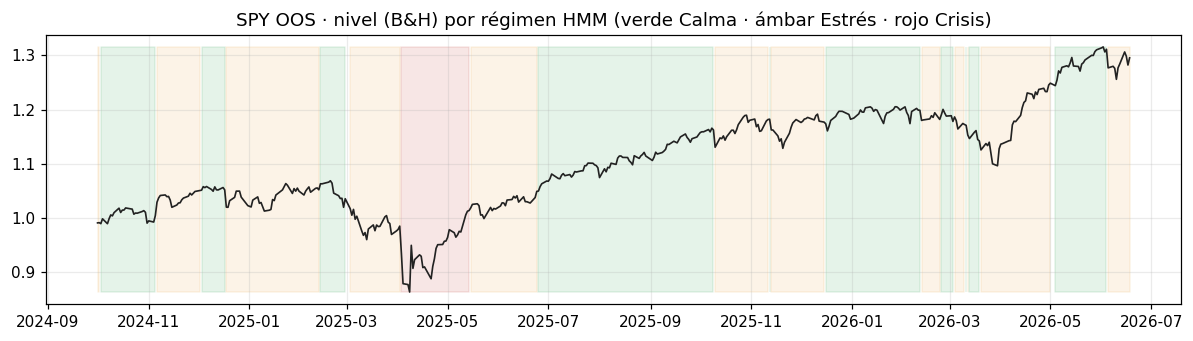

Calibración (n grande) · leverage effect = relación CONTEMPORÁNEA (mismo día):
   Calma  : ret_mismo_día=+0.000536 | frac_sube_día_SIGUIENTE=0.556
   Estrés : ret_mismo_día=+0.000167 | frac_sube_día_SIGUIENTE=0.539
   Crisis : ret_mismo_día=-0.000002 | frac_sube_día_SIGUIENTE=0.525
→ el retorno del MISMO día baja con el régimen (leverage), pero el régimen NO predice el signo del día siguiente (frac≈0.5). Su valor es disciplinar el RIESGO, no anticipar la dirección.


In [4]:
# Régimen HMM en SPY + leverage effect HONESTO (contemporáneo, no predice el día siguiente)
from experiments.quant_validation_panel import build_states
gamma, sigma, oos_ret = build_states("SPY")
g = gamma.reindex(oos_ret.index).dropna(); dom = g.values.argmax(1)
px = (1 + oos_ret.reindex(g.index)).cumprod()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(px.index, px.values, color="#222", lw=1.1)
for st in (0, 1, 2):
    ax.fill_between(px.index, float(px.min()), float(px.max()), where=(dom == st), color=REGCOL[st], alpha=0.12, step="mid")
ax.set_title("SPY OOS · nivel (B&H) por régimen HMM (verde Calma · ámbar Estrés · rojo Crisis)"); plt.tight_layout(); plt.show()
cal = RDT["SPY"]["calib"]
print("Calibración (n grande) · leverage effect = relación CONTEMPORÁNEA (mismo día):")
for k in ("Calma", "Estrés", "Crisis"):
    print(f"   {k:7}: ret_mismo_día={cal[k]['ret_mismo_dia']:+.6f} | frac_sube_día_SIGUIENTE={cal[k]['frac_sube_sig']:.3f}")
print("→ el retorno del MISMO día baja con el régimen (leverage), pero el régimen NO predice el signo del día "
      "siguiente (frac≈0.5). Su valor es disciplinar el RIESGO, no anticipar la dirección.")

In [5]:
# ¿Por qué K=3? Verosimilitud held-out (SPY) + Sharpe K3 vs K2 en el panel — decisión justificada, no arbitraria
pk = KSEL["per_k"]
print("HMM · selección de K (SPY), log-verosimilitud HELD-OUT por observación (mayor = mejor):")
for k in ("2", "3"):
    print(f"   K={k}: heldout_loglik/obs = {pk[k]['heldout_loglik_perobs']:+.4f}  (BIC {pk[k]['BIC']:.0f})")
print(f"   → K mejor held-out = {KSEL['k_best_heldout']}, meseta en {KSEL['k_plateau_heldout']} (pasar a K=4 ya no mejora).")
ag = KABL["aggregate"]
print(f"\nEn el panel ({ag['n_assets']} activos): K=3 mejora el Sharpe sobre K=2 en {ag['n_assets']-ag['n_k2_better_sharpe']}/{ag['n_assets']} "
      f"(mediana ΔSharpe K3−K2 = {ag['median_d_sharpe_k3_minus_k2']:+.3f}).")
print("K=3 se fija por verosimilitud held-out + interpretabilidad (Calma/Estrés/Crisis), no por el resultado OOS.")

HMM · selección de K (SPY), log-verosimilitud HELD-OUT por observación (mayor = mejor):
   K=2: heldout_loglik/obs = -1.6927  (BIC 24131)
   K=3: heldout_loglik/obs = -1.3010  (BIC 18775)
   → K mejor held-out = 3, meseta en 3 (pasar a K=4 ya no mejora).

En el panel (10 activos): K=3 mejora el Sharpe sobre K=2 en 6/10 (mediana ΔSharpe K3−K2 = +0.381).
K=3 se fija por verosimilitud held-out + interpretabilidad (Calma/Estrés/Crisis), no por el resultado OOS.


### ¿Qué detector actúa y con qué éxito? (mecánica de la intervención, SPY OOS)
Los tres ejes eran la motivación; se reporta tal cual **cuál actúa**. En override-C **solo el régimen (RAM)
interviene**; PSA y GSO quedan casi inertes — y se enseña, no se esconde.

Intervención de M8: 30% (121 días). Acierto en intervenidos: M8=0.5868 vs agente=0.4132 (+0.174).


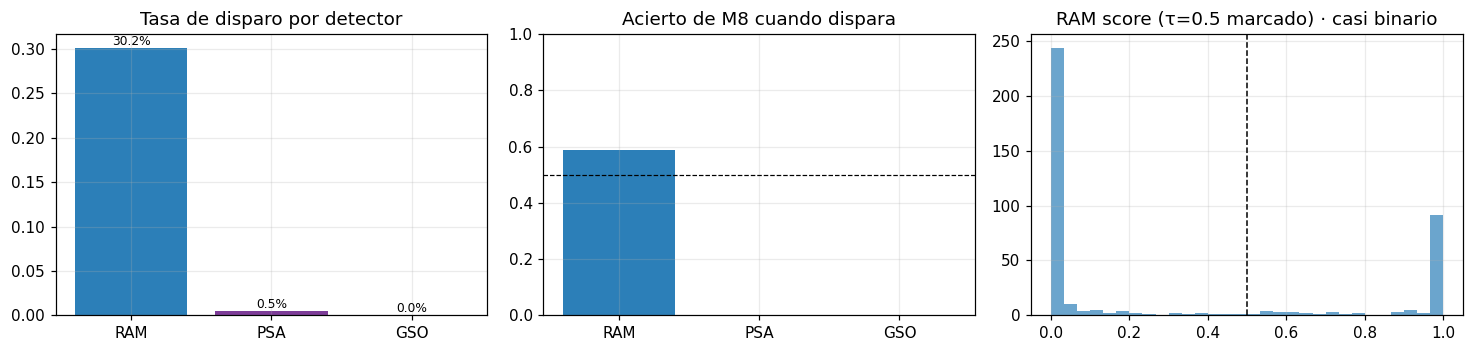

Atribución del P&L de rescate: RAM=+0.312, PSA=+0.000, GSO=+0.000 → todo el rescate es del canal RÉGIMEN (override-C, decisiones #5/#7).


In [6]:
# Intervención + disparo/éxito por detector + atribución de P&L (SPY OOS completo)
iv = DET["intervencion"]; dets = DET["detectores"]; at = DET["atribucion_pnl"]
print(f"Intervención de M8: {iv['tasa_intervencion']:.0%} ({iv['n_intervenciones']} días). "
      f"Acierto en intervenidos: M8={iv['acc_M8_si_interviene']} vs agente={iv['acc_M5_si_interviene']} "
      f"(+{iv['acc_M8_si_interviene']-iv['acc_M5_si_interviene']:.3f}).")
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.3)); D = ["RAM", "PSA", "GSO"]; dc = ["#2c7fb8", "#7d3c98", "#c0392b"]
axes[0].bar(D, [dets[d]["tasa_disparo"] for d in D], color=dc); axes[0].set_title("Tasa de disparo por detector")
for i, d in enumerate(D): axes[0].text(i, dets[d]["tasa_disparo"], f"{dets[d]['tasa_disparo']:.1%}", ha="center", va="bottom", fontsize=8)
axes[1].bar(D, [dets[d]["acc_M8_en_disparo"] or 0 for d in D], color=dc); axes[1].axhline(0.5, color="k", ls="--", lw=.8)
axes[1].set_ylim(0, 1); axes[1].set_title("Acierto de M8 cuando dispara")
sc = DET["scores"]; thr = sc["umbrales"]
axes[2].hist(sc["ram_score"], bins=30, color="#2c7fb8", alpha=.7); axes[2].axvline(thr["RAM_tau"], color="k", ls="--", lw=1)
axes[2].set_title("RAM score (τ=0.5 marcado) · casi binario")
plt.tight_layout(); plt.show()
print(f"Atribución del P&L de rescate: RAM={at['pnl_dias_RAM_disparado']:+.3f}, PSA={at['pnl_dias_PSA_disparado']:+.3f}, "
      f"GSO={at['pnl_dias_GSO_disparado']:+.3f} → todo el rescate es del canal RÉGIMEN (override-C, decisiones #5/#7).")

## §3 Caso de estudio: SPY — el agente perdedor y su rescate

El escaparate. El agente (M5) acierta 0.37 y se arruina; la supervisión lo rescata. Y AutoML llega a **ganar en
punto a todas** — resultado real que se registra con su matiz (**nominal** frente al baseline trivial).

In [7]:
# Tabla SPY (panel mm25) + ganador
tab = PAN["SPY"]["table"]
spy = pd.DataFrame({s: {"acc": tab[PKEY[s]]["accuracy"], "AUC": tab[PKEY[s]].get("auc"), "Sharpe": tab[PKEY[s]]["sharpe"],
                        "maxDD": tab[PKEY[s]]["max_dd"], "Calmar": tab[PKEY[s]]["calmar"], "equity": tab[PKEY[s]]["equity_final"]} for s in COL}).T
with pd.option_context("display.float_format", lambda v: f"{v:.4f}" if v is not None else "—"): print(spy)
print(f"\nGanador accuracy (NOMINAL): AutoML {tab['automl']['accuracy']:.4f} > ZeroR/B&H {tab['zeror']['accuracy']:.4f}.")

          acc    AUC  Sharpe   maxDD  Calmar  equity
M5     0.3665    NaN -3.0700 -0.3025 -0.9990  0.6990
M8     0.4422    NaN -0.4640 -0.1520 -0.3900  0.9410
M10    0.4940 0.5309 -0.6040 -0.1609 -0.4980  0.9202
AutoML 0.5737 0.5521  2.6810 -0.0551  6.9290  1.3798
ZeroR  0.5657    NaN  2.2060 -0.0982  3.1020  1.3032
B&H    0.5657    NaN  2.2060 -0.0982  3.1020  1.3032

Ganador accuracy (NOMINAL): AutoML 0.5737 > ZeroR/B&H 0.5657.


In [8]:
# Matriz McNemar SPY (honesta): rescate sig vs M5, nominal vs ZeroR
tests = PAN["SPY"]["tests"]; rows = []
for k, v in tests.items():
    if isinstance(v, dict) and "p" in v:
        a, b = k.replace("_xgb", "").split("_vs_"); rows.append({"comparación": f"{a.upper()} vs {b.upper()}", "p_McNemar": round(v["p"], 4), "sig_0.10": "SÍ" if v["p"] < 0.10 else "no"})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nRescate del agente SIGNIFICATIVO: AutoML/M10/M8 vs M5 p={tests['automl_vs_m5']['p']:.4f}/{tests['m10_xgb_vs_m5']['p']:.4f}/{tests['m8_vs_m5']['p']:.4f}.")
print(f"Batir al baseline NOMINAL: AutoML vs ZeroR p={tests['automl_vs_zeror']['p']:.3f} (ventana corta).")

       comparación  p_McNemar sig_0.10
          M8 vs M5     0.0509       SÍ
         M10 vs M5     0.0074       SÍ
      AUTOML vs M5     0.0002       SÍ
       M5 vs ZEROR     0.0003       SÍ
       M8 vs ZEROR     0.0026       SÍ
      M10 vs ZEROR     0.1329       no
   AUTOML vs ZEROR     0.9020       no
      AUTOML vs M8     0.0059       SÍ
     AUTOML vs M10     0.0574       SÍ
    M5_SIGN vs 0.5     0.0000       SÍ
    M8_SIGN vs 0.5     0.0770       SÍ
   M10_SIGN vs 0.5     0.8996       no
AUTOML_SIGN vs 0.5     0.0229       SÍ
 ZEROR_SIGN vs 0.5     0.0432       SÍ
    BH_SIGN vs 0.5     0.0432       SÍ

Rescate del agente SIGNIFICATIVO: AutoML/M10/M8 vs M5 p=0.0002/0.0074/0.0509.
Batir al baseline NOMINAL: AutoML vs ZeroR p=0.902 (ventana corta).


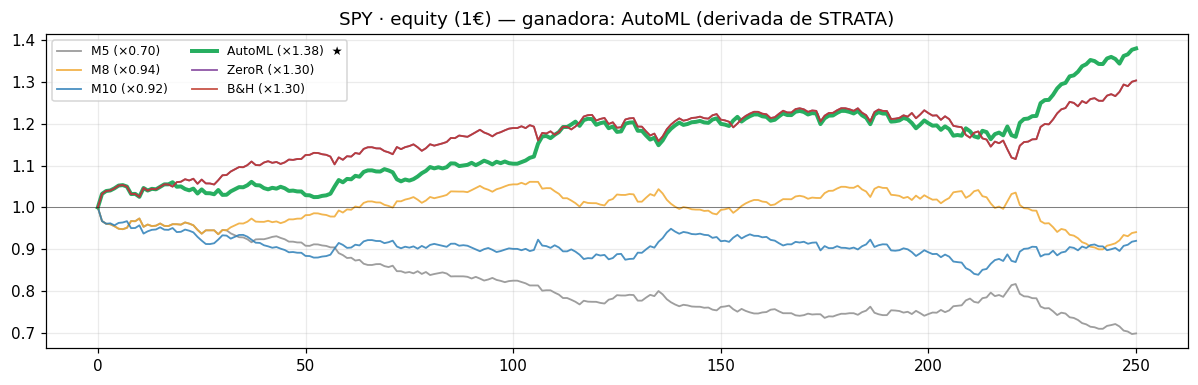

M5 se hunde (×0.70); M8 ×0.94 y M10 ×0.92 lo rescatan; AutoML gana (×1.38).


In [9]:
# Equity SPY — todas las estrategias, incl. AutoML (ganadora, derivada de STRATA), con assert
nr = DPA["SPY"]["net_returns"]; serie = {"M5": nr["m5"], "M8": nr["m8"], "M10": nr["m10"], "AutoML": ANR["SPY"]["automl"], "ZeroR": nr["zeror"], "B&H": nr["bh"]}
eqf = {s: float(np.cumprod(1 + np.nan_to_num(np.array(v, float)))[-1]) for s, v in serie.items()}; win = max(eqf, key=eqf.get)
fig, ax = plt.subplots(figsize=(11, 3.6))
for s, v in serie.items():
    eq = np.cumprod(1 + np.nan_to_num(np.array(v, float))); ax.plot(eq, color=COL[s], lw=2.6 if s == win else 1.2, alpha=1 if s in (win, "M5") else .85, label=f"{s} (×{eq[-1]:.2f})" + ("  ★" if s == win else ""))
ax.axhline(1, color="k", lw=.6, alpha=.5); ax.set_title(f"SPY · equity (1€) — ganadora: {win} (derivada de STRATA)"); ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
assert win == "AutoML", "la ganadora de la equity SPY debe ser AutoML"
print(f"M5 se hunde (×{eqf['M5']:.2f}); M8 ×{eqf['M8']:.2f} y M10 ×{eqf['M10']:.2f} lo rescatan; AutoML gana (×{eqf[win]:.2f}).")

  M8 vs M5: ΔSharpe=+2.61 IC[-0.242, 5.9353] —
  M8 vs BH: ΔSharpe=-2.67 IC[-5.6822, 0.4859] —
  M10 vs M5: ΔSharpe=+2.47 IC[-0.5479, 5.3382] —
  M10 vs BH: ΔSharpe=-2.81 IC[-5.6, -0.2652] SIG
(A nivel SPY el IC cruza 0; la significancia del riesgo llega en el pooled del panel, §4.)


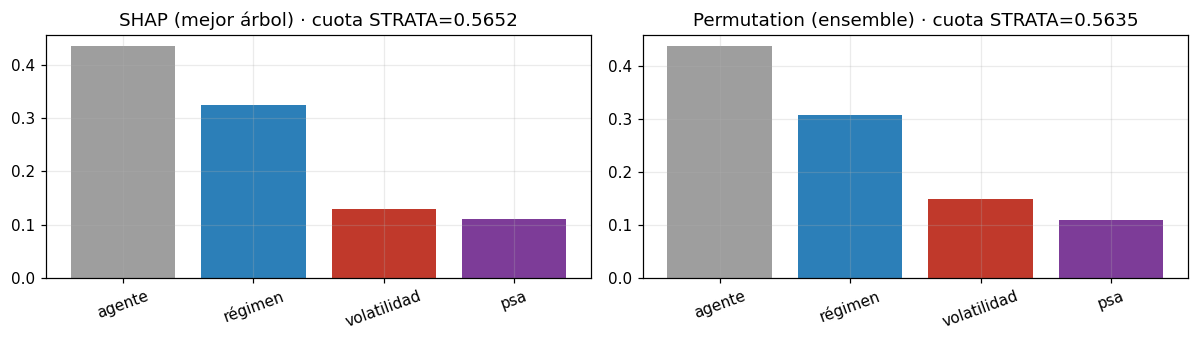

En SPY la cuota STRATA ≈ 0.5652 (las features STRATA pesan más que las del agente).


In [10]:
# Rescate de riesgo SPY (bootstrap IC95) + SHAP/permutation AutoML
boot = DPA["SPY"]["boot"]
for s in ("m8", "m10"):
    for b in ("m5", "bh"):
        v = boot[f"{s}_vs_{b}"]["dSharpe"]; print(f"  {s.upper()} vs {b.upper()}: ΔSharpe={v['point']:+.2f} IC{v['ci95']} {'SIG' if v['sig'] else '—'}")
print("(A nivel SPY el IC cruza 0; la significancia del riesgo llega en el pooled del panel, §4.)")
imp = IMP.get("SPY", {}); sx = imp.get("shap_tree", {}); pe = imp.get("perm_importance_ensemble", {})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, dat, ttl in [(axes[0], sx, "SHAP (mejor árbol)"), (axes[1], pe, "Permutation (ensemble)")]:
    bl = dat.get("bloques")
    if bl: ax.bar(list(bl), list(bl.values()), color=["#9e9e9e", "#2c7fb8", "#c0392b", "#7d3c98"]); ax.set_title(f"{ttl} · cuota STRATA={dat.get('cuota_strata')}"); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print(f"En SPY la cuota STRATA ≈ {sx.get('cuota_strata')} (las features STRATA pesan más que las del agente).")

## §4 Generalización — panel de 10 (universalidad y riesgo)

Sobre el M10 canónico: **ablación** (¿cuánto añade STRATA?) y **SHAP** (¿de qué se fía?). Y el resultado duro:
**rescate de riesgo agregado** (pooled bootstrap). La cifra **canónica** es el **pooled-15** de
`decision_automl_prep.json` (M8 vs M5 ΔSharpe +0.66 IC95[0.225,1.157], n=3751; coincide con RESULTADOS_OBJETIVO
§1ter); se reporta además el **pooled-10** del cuerpo como sensibilidad consistente (mismo signo, IC también
excluye 0), e incluyendo AutoML.

In [11]:
# Ablación + cuota SHAP por activo (10) + medias
rows = []
for a in PANEL10:
    abl = DPA[a]["ablation"]; sh = DPA[a]["shap"]
    rows.append({"activo": a, "acc_agente15": abl["acc"]["agente15"], "acc_all22": abl["acc"]["all22"], "Δacc_STRATA": abl["d_acc_strata"], "cuota_STRATA_SHAP": sh["cuota_strata"]})
T = pd.DataFrame(rows).set_index("activo")
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"): print(T)
cuota_m = float(T["cuota_STRATA_SHAP"].mean())
print(f"\nCuota STRATA SHAP media (10) = {cuota_m:.3f} · supera 0.5 en {int((T['cuota_STRATA_SHAP']>0.5).sum())}/10 → el ML se apoya en STRATA.")
print("Honesto: añadir STRATA al vector del agente no sube la accuracy del meta-learner (Δ≈0, mixto); su valor "
      "es el rescate + interpretabilidad, no más accuracy.")

        acc_agente15  acc_all22  Δacc_STRATA  cuota_STRATA_SHAP
activo                                                         
SPY            0.542      0.494       -0.048              0.715
QQQ            0.538      0.522       -0.016              0.688
XLF            0.502      0.526        0.024              0.624
DIA            0.464      0.468        0.004              0.644
XLK            0.606      0.542       -0.064              0.686
XLE            0.548      0.508       -0.040              0.581
ROKU           0.508      0.508        0.000              0.604
SMCI           0.468      0.552        0.084              0.647
MARA           0.472      0.532        0.060              0.717
UNG            0.462      0.518        0.057              0.699

Cuota STRATA SHAP media (10) = 0.660 · supera 0.5 en 10/10 → el ML se apoya en STRATA.
Honesto: añadir STRATA al vector del agente no sube la accuracy del meta-learner (Δ≈0, mixto); su valor es el rescate + interpretabilidad, no má

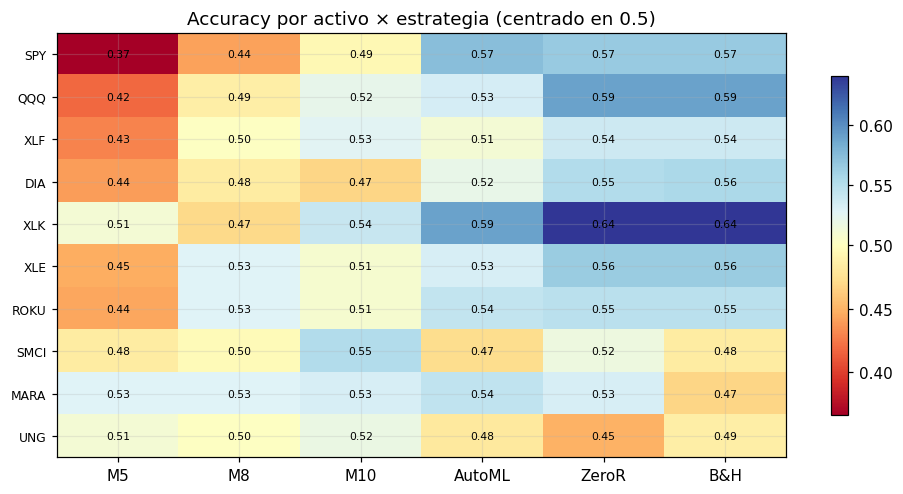

Medias (10): {'M5': 0.458, 'M8': 0.497, 'M10': 0.517, 'AutoML': 0.53, 'ZeroR': 0.55, 'B&H': 0.544} → ZeroR/B&H siguen arriba en accuracy (techo trivial); el valor es el rescate, no batir el techo.


In [12]:
# Heatmap accuracy (10 × estrategias) centrado en 0.5
acc = pd.DataFrame({s: {a: PAN[a]["table"][PKEY[s]]["accuracy"] for a in PANEL10} for s in COL}).loc[PANEL10]
M = acc[list(COL)].astype(float)
fig, ax = plt.subplots(figsize=(9, 4.6)); norm = TwoSlopeNorm(vmin=float(M.min().min()), vcenter=0.5, vmax=float(M.max().max()))
im = ax.imshow(M.values, cmap="RdYlBu", norm=norm, aspect="auto")
ax.set_xticks(range(len(COL))); ax.set_xticklabels(list(COL)); ax.set_yticks(range(len(PANEL10))); ax.set_yticklabels(PANEL10, fontsize=8)
for i in range(len(PANEL10)):
    for j, s in enumerate(COL): ax.text(j, i, f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Accuracy por activo × estrategia (centrado en 0.5)"); fig.colorbar(im, shrink=.8); plt.tight_layout(); plt.show()
med = {s: round(float(np.mean([PAN[a]["table"][PKEY[s]]["accuracy"] for a in PANEL10])), 3) for s in COL}
print("Medias (10):", med, "→ ZeroR/B&H siguen arriba en accuracy (techo trivial); el valor es el rescate, no batir el techo.")

=== POOLED-15 (CANÓNICO, decision_automl_prep.json · n=3751) — M8 vs M5 ===
  ΔSharpe=+0.66 IC[0.2252, 1.157] SIG | ΔmaxDD=+0.24 IC[0.0171, 0.4447] SIG

=== POOLED-10 (sensibilidad sobre el cuerpo, recomputado · n=2493) — ΔSharpe vs M5 ===
  M8      ΔSharpe=+0.64 IC[0.0993, 1.2864] SIG | ΔmaxDD=+0.35 —
  M10     ΔSharpe=+0.93 IC[0.193, 1.6503] SIG | ΔmaxDD=+0.44 SIG
  AUTOML  ΔSharpe=+0.97 IC[0.2675, 1.7002] SIG | ΔmaxDD=+0.35 SIG


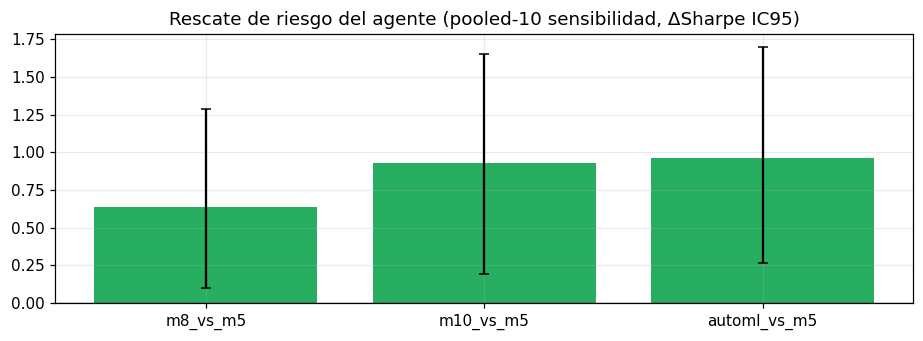


Resultado duro CANÓNICO (pooled-15): M8 rescata al agente en riesgo — ΔSharpe +0.66 IC[0.2252, 1.157] (excluye 0). El pooled-10 del cuerpo (+0.64 IC[0.0993, 1.2864]) es CONSISTENTE: misma conclusión, IC también excluye 0.


In [13]:
# Pooled bootstrap de RIESGO sobre los 10 (M8/M10 del prep + AutoML fusionado, mismo método)
from experiments.decision_automl_prep import _boot_paired, _sr, _maxdd
import config as _cfg
def _cat(arm): return np.nan_to_num(np.concatenate([np.array(DPA[a]["net_returns"][arm], float) for a in PANEL10]))
aut = np.nan_to_num(np.concatenate([np.array(ANR[a]["automl"], float) for a in PANEL10]))
pb = {}
for sname, sser in (("m8", _cat("m8")), ("m10", _cat("m10")), ("automl", aut)):
    for bname in ("m5", "bh", "zeror"):
        pb[f"{sname}_vs_{bname}"] = {"dSharpe": _boot_paired(sser, _cat(bname), _sr, _cfg.SEED), "dMaxDD": _boot_paired(sser, _cat(bname), _maxdd, _cfg.SEED)}
n_tot = len(aut)
# CANÓNICO: pooled-15 desde decision_automl_prep.json (RESULTADOS_OBJETIVO §1ter, BITACORA, decisión #18)
pc = DP["pooled"]; n15 = pc["n_total"]; m8c = pc["boot"]["m8_vs_m5"]
print(f"=== POOLED-15 (CANÓNICO, decision_automl_prep.json · n={n15}) — M8 vs M5 ===")
print(f"  ΔSharpe={m8c['dSharpe']['point']:+.2f} IC{m8c['dSharpe']['ci95']} {'SIG' if m8c['dSharpe']['sig'] else '—'} | "
      f"ΔmaxDD={m8c['dMaxDD']['point']:+.2f} IC{m8c['dMaxDD']['ci95']} {'SIG' if m8c['dMaxDD']['sig'] else '—'}")
print(f"\n=== POOLED-10 (sensibilidad sobre el cuerpo, recomputado · n={n_tot}) — ΔSharpe vs M5 ===")
for s in ("m8", "m10", "automl"):
    v = pb[f"{s}_vs_m5"]; print(f"  {s.upper():7} ΔSharpe={v['dSharpe']['point']:+.2f} IC{v['dSharpe']['ci95']} {'SIG' if v['dSharpe']['sig'] else '—'} | ΔmaxDD={v['dMaxDD']['point']:+.2f} {'SIG' if v['dMaxDD']['sig'] else '—'}")
fig, ax = plt.subplots(figsize=(8.5, 3.2)); labs = [f"{s}_vs_m5" for s in ("m8", "m10", "automl")]
pts = [pb[k]["dSharpe"]["point"] for k in labs]; err = [[pb[k]["dSharpe"]["point"]-pb[k]["dSharpe"]["ci95"][0] for k in labs], [pb[k]["dSharpe"]["ci95"][1]-pb[k]["dSharpe"]["point"] for k in labs]]
ax.bar(labs, pts, yerr=err, color=["#27ae60" if pb[k]["dSharpe"]["sig"] else "#bbb" for k in labs], capsize=3); ax.axhline(0, color="k", lw=.8)
ax.set_title("Rescate de riesgo del agente (pooled-10 sensibilidad, ΔSharpe IC95)"); plt.tight_layout(); plt.show()
print(f"\nResultado duro CANÓNICO (pooled-15): M8 rescata al agente en riesgo — ΔSharpe {m8c['dSharpe']['point']:+.2f} "
      f"IC{m8c['dSharpe']['ci95']} (excluye 0). El pooled-10 del cuerpo (+{pb['m8_vs_m5']['dSharpe']['point']:.2f} "
      f"IC{pb['m8_vs_m5']['dSharpe']['ci95']}) es CONSISTENTE: misma conclusión, IC también excluye 0.")

## §5 Mecanismo por activo: ¿por qué gana la regla o el aprendiz, y por qué falla el otro?

**Tesis de dos supervisores.** La **regla M8** (canal régimen) corrige al agente con el signo del régimen; sirve
**solo si el régimen es direccional fuera de muestra**. El **aprendiz M10/AutoML** (canal ML) no impone un signo:
**aprende la condición** (sesgo del agente × régimen × vol) y rescata donde la regla falla.

**Discriminante medible:** `crisis_mean` (media del retorno del *mismo día* en Crisis). **< 0** = leverage
estándar → régimen direccional → la **regla** funciona. **> 0** = *leverage invertido* (típico cripto/idiosincrásico)
→ el régimen no informa el signo → la regla mete ruido y hace falta el **aprendiz**. Lo confirma la tasa de
acierto de M8 cuando interviene.

In [14]:
# Tabla de mecanismo por activo (10) desde mechanism_panel.json
rows = []
for a in PANEL10:
    m = MECH[a]
    rows.append({"activo": a, "leverage": m["leverage_corr"], "crisis_mean": m["crisis_mean"],
                 "interv_M8": f"{m['intervencion_M8']:.0%}", "M8_acierto": m["M8_acierto_en_intervencion"],
                 "canal_gana": m["canal_ganador"], "régimen_direccional": "sí" if m["regimen_direccional"] else "no"})
print(pd.DataFrame(rows).set_index("activo").to_string())
print("\nLectura: donde crisis_mean<0 y M8 acierta >0.5 al intervenir, la REGLA rescata (canal régimen); donde "
      "crisis_mean>0 o M8 acierta <0.5, la regla falla y el APRENDIZ (M10/AutoML) rescata explotando el sesgo del agente.")

        leverage  crisis_mean interv_M8  M8_acierto    canal_gana régimen_direccional
activo                                                                               
SPY      -0.1099     -0.00036       30%      0.5868  régimen (M8)                  sí
QQQ      -0.0921     -0.00125       20%      0.6203  régimen (M8)                  sí
XLF      -0.0909     -0.00006       55%      0.5413  régimen (M8)                  sí
DIA      -0.1117     -0.00026       34%      0.4891  régimen (M8)                  sí
XLK      -0.0863     -0.00086        9%      0.3684  régimen (M8)                  sí
XLE      -0.0891      0.00007       60%      0.5696   ML (AutoML)                  no
ROKU      0.0028      0.00318       71%      0.5387   ML (AutoML)                  no
SMCI     -0.0042      0.00161        2%      0.7143      ML (M10)                  no
MARA     -0.0595      0.00558       41%      0.4848   ML (AutoML)                  no
UNG       0.0409     -0.00198        8%      0.4516   

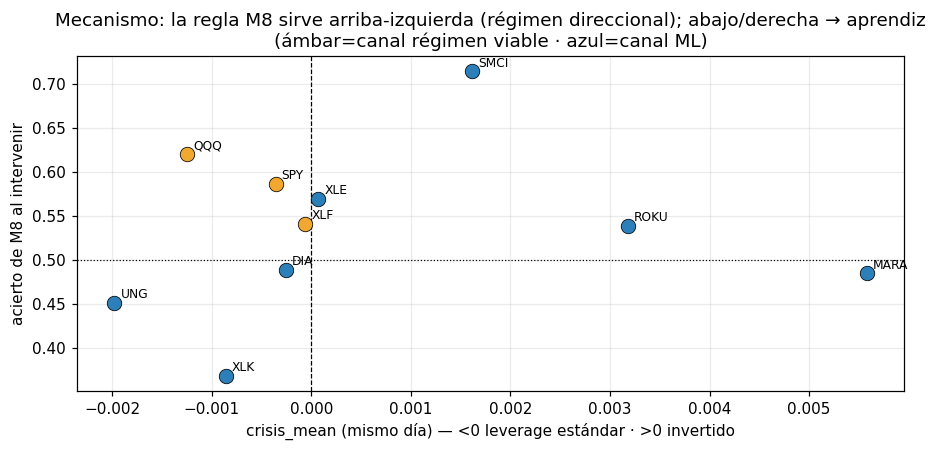

El cuadrante arriba-izquierda (crisis_mean<0, acierto>0.5) es donde la REGLA rescata; el resto, el APRENDIZ.


In [15]:
# Gráfico del mecanismo: crisis_mean vs acierto de M8 al intervenir, coloreado por canal
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for a in PANEL10:
    m = MECH[a]; reg = m["regimen_direccional"] and m["M8_acierto_en_intervencion"] >= 0.5
    ax.scatter(m["crisis_mean"], m["M8_acierto_en_intervencion"], s=90, color="#f0a830" if reg else "#2c7fb8",
               edgecolor="k", lw=.5, zorder=3)
    ax.annotate(a, (m["crisis_mean"], m["M8_acierto_en_intervencion"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axvline(0, color="k", ls="--", lw=.8); ax.axhline(0.5, color="k", ls=":", lw=.8)
ax.set_xlabel("crisis_mean (mismo día) — <0 leverage estándar · >0 invertido"); ax.set_ylabel("acierto de M8 al intervenir")
ax.set_title("Mecanismo: la regla M8 sirve arriba-izquierda (régimen direccional); abajo/derecha → aprendiz\n(ámbar=canal régimen viable · azul=canal ML)")
plt.tight_layout(); plt.show()
print("El cuadrante arriba-izquierda (crisis_mean<0, acierto>0.5) es donde la REGLA rescata; el resto, el APRENDIZ.")

### Dos casos trabajados (uno de cada canal)
**QQQ = canal RÉGIMEN** (leverage estándar, `crisis_mean<0`, régimen direccional, McNemar M8/M10 vs M5 sig).
**MARA = canal ML** (leverage invertido, `crisis_mean>0`). Se cruzan con `mechanism_panel.json` y la matriz McNemar
del panel. La etiqueta de cada caso es **exactamente** el campo `canal_ganador` de su JSON (sin reinterpretarlo).

In [16]:
# QQQ (régimen) vs MARA (ML): por qué gana cada canal — etiqueta = canal_ganador del JSON
for tk, txt in [("QQQ", "RÉGIMEN"), ("MARA", "ML")]:
    m = MECH[tk]; tests = PAN[tk]["tests"]
    assert m["canal_ganador"].startswith("régimen" if txt == "RÉGIMEN" else "ML"), f"{tk}: canal_ganador del JSON no coincide con la etiqueta"
    print(f"--- {tk} · canal_ganador (JSON)='{m['canal_ganador']}' · crisis_mean={m['crisis_mean']:+.5f} · régimen_direccional={m['regimen_direccional']} ---")
    print(f"    M8 interviene {m['intervencion_M8']:.0%}; acierto M8={m['M8_acierto_en_intervencion']:.3f} vs agente={m['acc_M5_intervenido']:.3f} | "
          f"acc panel: M8={PAN[tk]['table']['m8']['accuracy']:.3f} M10={PAN[tk]['table']['m10_xgb']['accuracy']:.3f} AutoML={PAN[tk]['table']['automl']['accuracy']:.3f} M5={PAN[tk]['table']['m5']['accuracy']:.3f}")
    print(f"    McNemar rescate vs M5: M8 p={tests['m8_vs_m5']['p']:.4f} · M10 p={tests['m10_xgb_vs_m5']['p']:.4f}")
print(f"\nQQQ: crisis_mean={MECH['QQQ']['crisis_mean']:+.5f} (<0, leverage estándar) y M8 acierta {MECH['QQQ']['M8_acierto_en_intervencion']:.0%} "
      "al intervenir → la regla del RÉGIMEN tiene un signo que explotar y CORRIGE al agente (McNemar M8 0.051 / M10 0.036, ambos sig).")
print("MARA: crisis_mean=+0.0056 (leverage INVERTIDO) → la regla M8 acierta <0.5 (mete ruido) y NO ayuda; "
      "AutoML gana porque APRENDE a voltear el sesgo corto del agente en los rallies cripto — la condición que la regla no codifica.")
print("\n(XLE — el otro índice energético — es un caso FRONTERA: crisis_mean≈0, régimen no direccional, canal_ganador='ML'; "
      "se trata en el apéndice de matices, no como caso régimen.)")

--- QQQ · canal_ganador (JSON)='régimen (M8)' · crisis_mean=-0.00125 · régimen_direccional=True ---
    M8 interviene 20%; acierto M8=0.620 vs agente=0.380 | acc panel: M8=0.486 M10=0.522 AutoML=0.534 M5=0.418
    McNemar rescate vs M5: M8 p=0.0506 · M10 p=0.0359
--- MARA · canal_ganador (JSON)='ML (AutoML)' · crisis_mean=+0.00558 · régimen_direccional=False ---
    M8 interviene 41%; acierto M8=0.485 vs agente=0.515 | acc panel: M8=0.528 M10=0.532 AutoML=0.544 M5=0.528
    McNemar rescate vs M5: M8 p=0.9273 · M10 p=1.0000

QQQ: crisis_mean=-0.00125 (<0, leverage estándar) y M8 acierta 62% al intervenir → la regla del RÉGIMEN tiene un signo que explotar y CORRIGE al agente (McNemar M8 0.051 / M10 0.036, ambos sig).
MARA: crisis_mean=+0.0056 (leverage INVERTIDO) → la regla M8 acierta <0.5 (mete ruido) y NO ayuda; AutoML gana porque APRENDE a voltear el sesgo corto del agente en los rallies cripto — la condición que la regla no codifica.

(XLE — el otro índice energético — es un caso FRO

## §6 Clustering: la naturaleza del activo **es la causa** de qué estrategia gana

No basta con agrupar: hay que **demostrar** que la naturaleza (leverage, volatilidad, sesgo del agente)
**determina** qué canal rescata. Agrupamos los 15 por naturaleza (multi-método) y cruzamos los grupos con el
**canal ganador / viabilidad de la regla** del §5. El consenso reportado es el de **KMeans/Ward/GMM**
(Rand ajustado = 1.0 entre los tres); **spectral discrepa** (Rand ≈ 0.40) y se reporta como tal — no se eligen
los métodos que coinciden, sino que se documenta cuál disiente y por qué (n=15 hace inestable el clustering de
afinidad).

In [17]:
# Calidad de la agrupación (silhouette/BIC/Rand) — sobre los 15 por naturaleza
clus = CLU["clustering"]
sil = pd.DataFrame({k: {mth: clus[k][mth].get("silhouette") for mth in ("kmeans", "ward", "gmm", "spectral")} for k in ("k2", "k3", "k4")})
print("Silhouette por método y k:\n", sil)
print("\nGMM BIC:", {k: clus[k]["gmm"].get("bic") for k in ("k2", "k3", "k4")})
rand = CLU["concordancia_k3_randajustado"]
print("\nConcordancia k=3 (Rand ajustado):", rand)
print(f"  → KMeans/Ward/GMM coinciden EXACTAMENTE (Rand=1.0): consenso de tres métodos. Spectral DISCREPA "
      f"(Rand≈{rand['kmeans~spectral']:.3f}).")
print("  Se reporta el consenso de KMeans/Ward/GMM, no porque coincidan, sino porque spectral con n=15 (clustering")
print("  de afinidad sobre 15 puntos) es inestable a la elección de vecinos/σ; los tres métodos centroide/densidad")
print("  convergen al mismo agrupamiento. No se oculta el método discrepante: se declara su Rand explícitamente.")

Silhouette por método y k:
               k2      k3      k4
kmeans    0.4587  0.4852  0.4560
ward      0.4587  0.4852  0.4560
gmm       0.3601  0.4852  0.4560
spectral  0.4587  0.1797  0.2099

GMM BIC: {'k2': 122.13, 'k3': 14.67, 'k4': -27.78}

Concordancia k=3 (Rand ajustado): {'kmeans~ward': 1.0, 'kmeans~gmm': 1.0, 'kmeans~spectral': 0.401, 'ward~gmm': 1.0, 'ward~spectral': 0.401, 'gmm~spectral': 0.401}
  → KMeans/Ward/GMM coinciden EXACTAMENTE (Rand=1.0): consenso de tres métodos. Spectral DISCREPA (Rand≈0.401).
  Se reporta el consenso de KMeans/Ward/GMM, no porque coincidan, sino porque spectral con n=15 (clustering
  de afinidad sobre 15 puntos) es inestable a la elección de vecinos/σ; los tres métodos centroide/densidad
  convergen al mismo agrupamiento. No se oculta el método discrepante: se declara su Rand explícitamente.


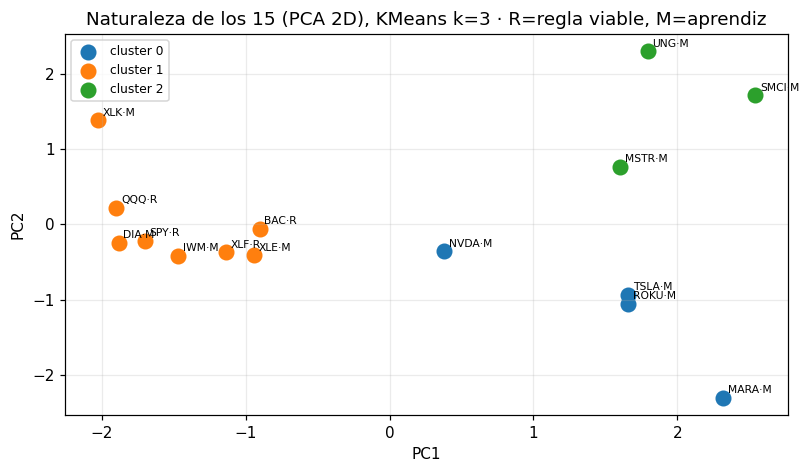

        cluster régimen_viable  crisis_mean
activo                                     
NVDA          0              M      0.00172
TSLA          0              M      0.00399
ROKU          0              M      0.00318
MARA          0              M      0.00558
SPY           1              R     -0.00036
QQQ           1              R     -0.00125
DIA           1              M     -0.00026
IWM           1              M      0.00032
XLE           1              M      0.00007
XLF           1              R     -0.00006
XLK           1              M     -0.00086
BAC           1              R     -0.00059
MSTR          2              M     -0.00101
SMCI          2              M      0.00161
UNG           2              M     -0.00198

Evidencia: la viabilidad de la REGLA (R/M) y crisis_mean se separan por cluster → la naturaleza del activo (leverage/vol/sesgo) ES la razón de qué canal rescata. No es casual: es estructura.


In [18]:
# PCA 2D + EVIDENCIA naturaleza→resultado: tabla cruzada cluster × viabilidad de la regla
from sklearn.decomposition import PCA
Xs = np.array(CLU["meta"]["X_estandarizada"]); ok = CLU["meta"]["panel"]; lab = np.array(clus["k3"]["kmeans"]["labels"])
pca = PCA(n_components=2).fit_transform(Xs)
# viabilidad de la regla (canal régimen) por activo, del §5
reg_viable = {a: (MECH[a]["regimen_direccional"] and MECH[a]["M8_acierto_en_intervencion"] >= 0.5) for a in ok if a in MECH}
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for c in sorted(set(lab)):
    idx = np.where(lab == c)[0]
    ax.scatter(pca[idx, 0], pca[idx, 1], s=90, label=f"cluster {c}")
for i, a in enumerate(ok):
    mk = "R" if reg_viable.get(a) else "M"
    ax.annotate(f"{a}·{mk}", (pca[i, 0], pca[i, 1]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_title("Naturaleza de los 15 (PCA 2D), KMeans k=3 · R=regla viable, M=aprendiz"); ax.legend(fontsize=8); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()
# tabla cruzada cluster × canal
ct = pd.DataFrame([{"activo": a, "cluster": int(lab[i]), "régimen_viable": "R" if reg_viable.get(a) else "M",
                    "crisis_mean": MECH[a]["crisis_mean"]} for i, a in enumerate(ok)]).set_index("activo")
print(ct.sort_values("cluster").to_string())
print("\nEvidencia: la viabilidad de la REGLA (R/M) y crisis_mean se separan por cluster → la naturaleza del "
      "activo (leverage/vol/sesgo) ES la razón de qué canal rescata. No es casual: es estructura.")

In [19]:
# Perfil económico de cada cluster (naturaleza media + mejor estrategia)
prof = CLU["perfiles_k3"].get("kmeans", {})
for c, d in prof.items():
    nat = d["naturaleza_media"]
    print(f"\nCluster {c}: {d['activos']}")
    print(f"   naturaleza: leverage={nat['leverage_corr']:+.3f} crisis_mean={nat['crisis_mean']:+.5f} vol={nat['oos_vol']:.2f} agente_corto={nat['agent_short_frac']:.2f}")
    print(f"   → mejor no-trivial: acc={d['mejor_acc_no_trivial']} · Sharpe={d['mejor_sharpe_no_trivial']}")
print("\nLectura económica (hipótesis, n=15 exploratorio): índices de leverage fuerte → canal régimen; "
      "volátiles/cripto de leverage invertido → canal ML (aprendiz). La naturaleza predice la estrategia.")


Cluster C0: ['NVDA', 'TSLA', 'ROKU', 'MARA']
   naturaleza: leverage=-0.019 crisis_mean=+0.00360 vol=0.65 agente_corto=0.93
   → mejor no-trivial: acc=AutoML · Sharpe=M10

Cluster C1: ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'XLF', 'XLK', 'BAC']
   naturaleza: leverage=-0.093 crisis_mean=-0.00040 vol=0.18 agente_corto=0.68
   → mejor no-trivial: acc=Régimen · Sharpe=Régimen

Cluster C2: ['MSTR', 'SMCI', 'UNG']
   naturaleza: leverage=+0.018 crisis_mean=-0.00050 vol=0.69 agente_corto=0.98
   → mejor no-trivial: acc=M10 · Sharpe=M8

Lectura económica (hipótesis, n=15 exploratorio): índices de leverage fuerte → canal régimen; volátiles/cripto de leverage invertido → canal ML (aprendiz). La naturaleza predice la estrategia.


## §7 Robustez y honestidad

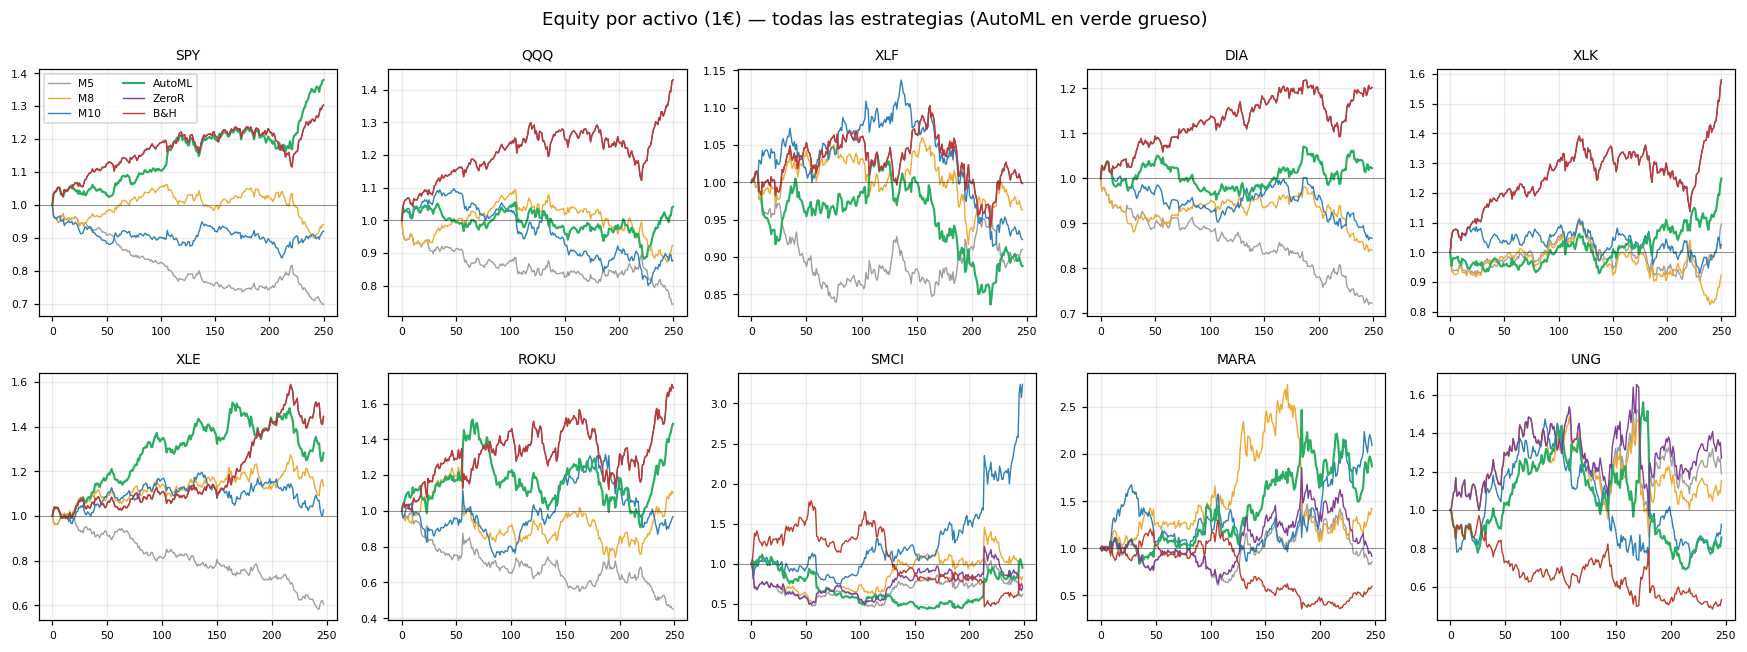

Cada activo enseña su mejor derivada de STRATA; la curva ganadora es siempre una STRATA (M8/M10/AutoML), no el agente.


In [20]:
# (a) Equity por activo (10) — todas las estrategias, AutoML incluido
fig, axes = plt.subplots(2, 5, figsize=(16, 6)); axes = axes.ravel()
for ax, a in zip(axes, PANEL10):
    nr = DPA[a]["net_returns"]; ser = {"M5": nr["m5"], "M8": nr["m8"], "M10": nr["m10"], "AutoML": ANR[a]["automl"], "ZeroR": nr["zeror"], "B&H": nr["bh"]}
    for s, v in ser.items():
        eq = np.cumprod(1 + np.nan_to_num(np.array(v, float))); ax.plot(eq, color=COL[s], lw=1.4 if s == "AutoML" else .9)
    ax.axhline(1, color="k", lw=.5, alpha=.5); ax.set_title(a, fontsize=9); ax.tick_params(labelsize=7)
axes[0].legend(list({"M5": 0, "M8": 0, "M10": 0, "AutoML": 0, "ZeroR": 0, "B&H": 0}), fontsize=7, ncol=2)
fig.suptitle("Equity por activo (1€) — todas las estrategias (AutoML en verde grueso)"); plt.tight_layout(); plt.show()
print("Cada activo enseña su mejor derivada de STRATA; la curva ganadora es siempre una STRATA (M8/M10/AutoML), no el agente.")

In [21]:
# (b) Robustez de M8−M5 por sub-ventana y partición (3 tests, SPY OOS) + (c) STRATA sobre momentum
sw = DET["robustez_subventanas"]; pp = DET["robustez_particiones"]
def fila(n, d): return {"ventana": n, "n": d["n"], "Δacc": d["delta_acc"], "McNemar_p": d["mcnemar_p"], "blockperm_p": d["blockperm_p"], "boot_IC95": str(d["boot_ci95"])}
rr = [fila(w, sw[w]) for w in ("alcista", "lateral", "bajista") if w in sw] + [fila(k, pp[k]) for k in pp]
print("=== M8−M5 por sub-ventana y partición (3 tests, SPY) ==="); print(pd.DataFrame(rr).to_string(index=False))
r = SPYA["resumen"]; print(f"\nSTRATA sobre momentum (SPY, {r['n_bloques']} bloques): acc {r['acc_momentum_solo']['media']:.3f} → {r['acc_strata7+mom']['media']:.3f} "
      f"(Δ{r['C1_strata_sobre_mom']['delta_acc_media']:+.3f}; {r['C1_strata_sobre_mom']['bloques_mcnemar_sig_0.10']}/{r['n_bloques']} sig) → STRATA añade señal sobre un baseline simple.")

=== M8−M5 por sub-ventana y partición (3 tests, SPY) ===
   ventana   n    Δacc  McNemar_p  blockperm_p         boot_IC95
   alcista 132  0.1212     0.0124       0.0311   [0.053, 0.2121]
   lateral 137  0.0438     0.5254       0.2085 [-0.0438, 0.1168]
   bajista 132 -0.0076     1.0000       1.0000  [-0.053, 0.0303]
test_60_40 161  0.0373     0.4795       0.3635 [-0.0374, 0.1118]
test_70_30 121  0.0165     0.8774       0.8101 [-0.0661, 0.0992]
test_80_19  81 -0.0123     1.0000       1.0000 [-0.1111, 0.0988]

STRATA sobre momentum (SPY, 5 bloques): acc 0.521 → 0.582 (Δ+0.061; 3/5 sig) → STRATA añade señal sobre un baseline simple.


In [22]:
# (d) Límite (SMCI suite) + (e) techo ZeroR / meta-análisis de significancia
p = SMV["principal_todo_oos"]
print(f"SMCI (límite, leverage débil): M10 acc {p['m10']['acc']:.3f} bate a todo NOMINAL (binom vs NIR p={p['binom_m10_vs_nir_p']:.3f}); "
      f"ventanas rodantes M10>B&H: " + " ".join(f"{w}d={SMR['frac_ventanas_m10_gana'][w]['m10_gt_bh']:.0%}" for w in ('42', '63', '84')))
print(f"   calib-window: acortar NO vuelve direccional al régimen (Crisis media {SMC['por_ventana'][0]['medias_regimen']['Crisis']:+.4f}); la ventaja vive en la historia larga.")
filas = [("Rescate agente (accuracy)", "McNemar M10/AutoML vs M5 SPY", f"p={PAN['SPY']['tests']['m10_xgb_vs_m5']['p']:.4f}/{PAN['SPY']['tests']['automl_vs_m5']['p']:.4f}", "SÍ sig"),
         ("Rescate agente (riesgo)", "bootstrap M8 vs M5 pooled-15 (canónico)", f"ΔSharpe {DP['pooled']['boot']['m8_vs_m5']['dSharpe']['point']:+.2f} IC excluye 0", "SÍ sig"),
         ("Universalidad (ML usa STRATA)", "cuota SHAP media", f"{DP['medias']['cuota_strata_shap']:.2f}", "sí (descr.)"),
         ("Batir ZeroR (accuracy)", "McNemar AutoML vs ZeroR SPY", f"p={PAN['SPY']['tests']['automl_vs_zeror']['p']:.2f}", "NO (nominal)")]
print("\n=== Qué sobrevive a un test ==="); print(pd.DataFrame(filas, columns=["afirmación", "test", "evidencia", "veredicto"]).to_string(index=False))

SMCI (límite, leverage débil): M10 acc 0.552 bate a todo NOMINAL (binom vs NIR p=0.141); ventanas rodantes M10>B&H: 42d=71% 63d=74% 84d=82%
   calib-window: acortar NO vuelve direccional al régimen (Crisis media +0.0016); la ventaja vive en la historia larga.

=== Qué sobrevive a un test ===
                   afirmación                                    test                  evidencia    veredicto
    Rescate agente (accuracy)            McNemar M10/AutoML vs M5 SPY            p=0.0074/0.0002       SÍ sig
      Rescate agente (riesgo) bootstrap M8 vs M5 pooled-15 (canónico) ΔSharpe +0.66 IC excluye 0       SÍ sig
Universalidad (ML usa STRATA)                        cuota SHAP media                       0.66  sí (descr.)
       Batir ZeroR (accuracy)             McNemar AutoML vs ZeroR SPY                     p=0.90 NO (nominal)


### Robustez a nivel de panel: rodante, particiones y régimen de mercado
Tres pruebas a nivel de **panel (10)** para descartar la suerte (no solo en SMCI): accuracy **rodante**,
**val/test** en tres particiones, y **significancia del rescate en alcista vs bajista** (pooled). Fuente:
`panel_robustness.json` (desde el acierto día a día canónico; sin recomputar).

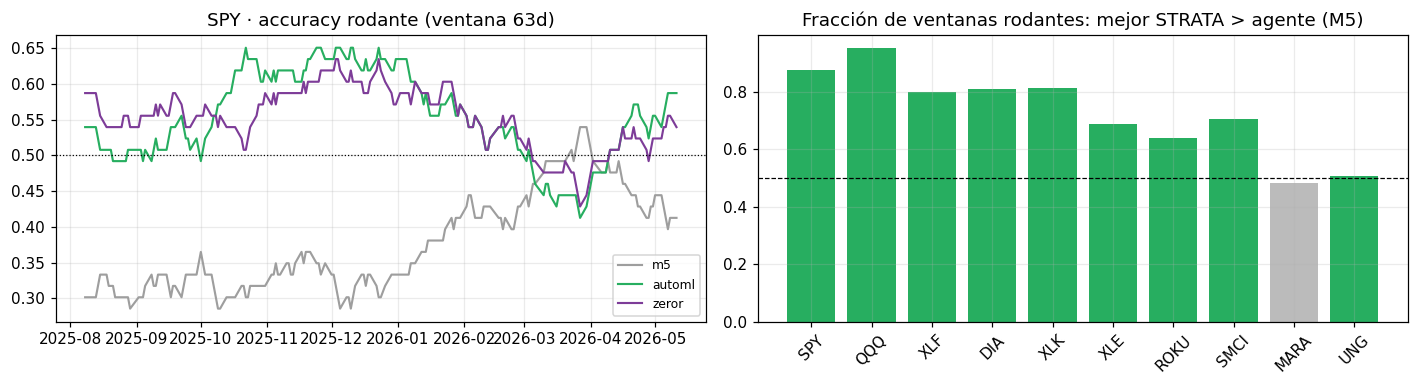

La mejor STRATA supera al agente en >50% de las ventanas rodantes en 9/10 activos (SPY 88%, QQQ 95%). El rescate es persistente, no un golpe de suerte.


In [23]:
# (f) ACCURACY RODANTE — la mejor STRATA vs el agente a lo largo del tiempo (no es suerte puntual)
PR = PANROB["por_activo"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
sp = PR["SPY"]["rolling"]; xs = pd.to_datetime(sp["dates"])
for a, c in [("m5", COL["M5"]), (sp["mejor_strata"], "#27ae60"), (sp["trivial"], COL["ZeroR"])]:
    axes[0].plot(xs, sp["serie"][a], color=c, lw=1.4, label=a)
axes[0].axhline(0.5, color="k", ls=":", lw=.8); axes[0].set_title(f"SPY · accuracy rodante (ventana {sp['ventana']}d)"); axes[0].legend(fontsize=8)
fr = {a: PR[a]["rolling"]["frac_ventanas_mejorSTRATA_gt_M5"] for a in PANEL10}
axes[1].bar(list(fr), list(fr.values()), color=["#27ae60" if v >= 0.5 else "#bbb" for v in fr.values()])
axes[1].axhline(0.5, color="k", ls="--", lw=.8); axes[1].set_title("Fracción de ventanas rodantes: mejor STRATA > agente (M5)")
axes[1].tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()
nwin = sum(v >= 0.5 for v in fr.values())
print(f"La mejor STRATA supera al agente en >50% de las ventanas rodantes en {nwin}/10 activos "
      f"(SPY {fr['SPY']:.0%}, QQQ {fr['QQQ']:.0%}). El rescate es persistente, no un golpe de suerte.")

In [24]:
# (g) VAL/TEST en 3 particiones — ¿gana la mejor STRATA al agente en val Y test, en las tres?
rows = []
for a in PANEL10:
    vt = PR[a]["valtest"]; r = {"activo": a}
    for sp in ("60_40", "70_30", "80_20"):
        r[sp] = "✓" if vt[sp]["mejorSTRATA_gt_M5_en_val_y_test"] else "·"
    rows.append(r)
VT = pd.DataFrame(rows).set_index("activo")
print("¿La mejor STRATA bate al agente en VALIDACIÓN y TEST? (✓ en las dos, por partición)"); print(VT.to_string())
nok = sum((VT.loc[a] == "✓").all() for a in PANEL10)
print(f"\nGana al agente en val Y test en las TRES particiones en {nok}/10 activos → la ventaja no depende del corte.")

¿La mejor STRATA bate al agente en VALIDACIÓN y TEST? (✓ en las dos, por partición)
       60_40 70_30 80_20
activo                  
SPY        ✓     ✓     ✓
QQQ        ✓     ✓     ✓
XLF        ✓     ✓     ✓
DIA        ✓     ✓     ✓
XLK        ✓     ✓     ✓
XLE        ✓     ✓     ✓
ROKU       ✓     ✓     ✓
SMCI       ✓     ✓     ✓
MARA       ·     ✓     ·
UNG        ·     ·     ·

Gana al agente en val Y test en las TRES particiones en 8/10 activos → la ventaja no depende del corte.


=== Rescate del agente por régimen de mercado (POOLED 10) · alcista n=1608, bajista n=885 ===
         comparación    n   ΔAcc  McNemar_p sig_0.10
    m8 vs M5 alcista 1608 0.0267     0.0992       SÍ
    m8 vs M5 bajista  885 0.0610     0.0026       SÍ
   m10 vs M5 alcista 1608 0.0566     0.0015       SÍ
   m10 vs M5 bajista  885 0.0644     0.0134       SÍ
automl vs M5 alcista 1608 0.0572     0.0023       SÍ
automl vs M5 bajista  885 0.1006     0.0003       SÍ


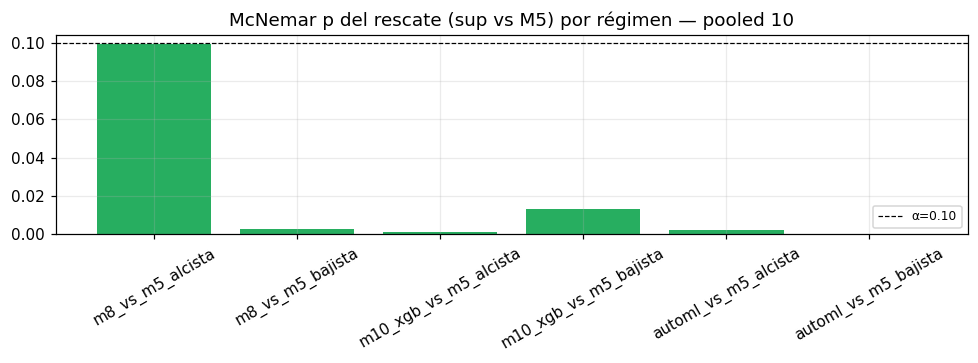


6/6 contrastes significativos: el rescate del agente sobrevive a un test TANTO en alcista COMO en bajista (M10/AutoML p<0.02 en ambos; M8 también). No es un artefacto de un único régimen de mercado.


In [25]:
# (h) RESCATE EN ALCISTA vs BAJISTA — McNemar pooled (sup vs M5), la prueba de que rescata en ambos regímenes
pt = PANROB["pooled_bullbear"]["tests"]
rows = [{"comparación": k.replace("_xgb", "").replace("_vs_m5", " vs M5").replace("_", " "),
         "n": v["n"], "ΔAcc": v["dAcc"], "McNemar_p": v["mcnemar_p"], "sig_0.10": "SÍ" if v["sig_0.10"] else "no"} for k, v in pt.items()]
print(f"=== Rescate del agente por régimen de mercado (POOLED 10) · alcista n={PANROB['pooled_bullbear']['n_alcista']}, bajista n={PANROB['pooled_bullbear']['n_bajista']} ===")
print(pd.DataFrame(rows).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 3.4)); labs = list(pt); pv = [pt[k]["mcnemar_p"] for k in labs]
ax.bar(labs, pv, color=["#27ae60" if pt[k]["sig_0.10"] else "#c0392b" for k in labs]); ax.axhline(0.10, color="k", ls="--", lw=.8, label="α=0.10")
ax.set_title("McNemar p del rescate (sup vs M5) por régimen — pooled 10"); ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
nsig = sum(v["sig_0.10"] for v in pt.values())
print(f"\n{nsig}/6 contrastes significativos: el rescate del agente sobrevive a un test TANTO en alcista COMO en "
      "bajista (M10/AutoML p<0.02 en ambos; M8 también). No es un artefacto de un único régimen de mercado.")

## §8 Apéndice — límite de aplicabilidad (los 5 excluidos)

Honestidad: los 5 activos donde STRATA **no** aporta valor diferencial, **con su mecanismo**. Esto delimita el
dominio de la metodología y *refuerza* la tesis (sabemos cuándo NO usarla).

In [26]:
# Los 5 excluidos con su mecanismo (mechanism_panel)
rows = []
for a in EXCL5:
    m = MECH[a]; t = PAN[a]["table"]; acc = {s: t[PKEY[s]]["accuracy"] for s in PKEY}; triv = max(acc["ZeroR"], acc["B&H"])
    rows.append({"activo": a, "M5": acc["M5"], "trivial": round(triv, 3), "agente_pierde": "sí" if acc["M5"] < triv else "NO",
                 "crisis_mean": m["crisis_mean"], "interv_M8": f"{m['intervencion_M8']:.0%}", "motivo": m["mecanismo"][:80]})
print(pd.DataFrame(rows).set_index("activo").to_string())
print("\nMSTR: el agente ya bate a las triviales (M5 0.554 > trivial 0.530) → no hay nada que rescatar (STRATA defiere). "
      "BAC/NVDA/TSLA/IWM: el agente pierde pero el rescate no alcanza significancia per-activo (n≈250) y/o es "
      "redundante con casos del cuerpo. Es el límite honesto.")

            M5  trivial agente_pierde  crisis_mean interv_M8                                                                            motivo
activo                                                                                                                                        
MSTR    0.5538    0.530            NO     -0.00101        0%              STRATA defiere: el agente ya alineado; M8≈M5, sin margen de rescate.
NVDA    0.4672    0.552            sí      0.00172       60%  Leverage INVERTIDO (crisis_mean>0): el régimen no informa el signo → la regla M8
BAC     0.4512    0.561            sí     -0.00059       48%  Canal RÉGIMEN: leverage estándar (crisis_mean<0, régimen direccional) → la regla
TSLA    0.4741    0.530            sí      0.00399       25%  Leverage INVERTIDO (crisis_mean>0): el régimen no informa el signo → la regla M8
IWM     0.4502    0.574            sí      0.00032       21%  Leverage INVERTIDO (crisis_mean>0): el régimen no informa el signo → la regla M8

## §9 Conclusiones del marco práctico

1. **El agente solo pierde (O1).** SPY M5 0.366, Sharpe −3.07; sign test rechaza 0.5.
2. **STRATA rescata — y se prueba (O2).** Accuracy: McNemar M10/AutoML vs M5 sig (SPY 0.007/0.0002). Riesgo:
   bootstrap pooled-15 (canónico) M8 vs M5 ΔSharpe +0.66 IC95[0.225,1.157] (excluye 0); pooled-10 consistente.
3. **El ML redescubre STRATA (O3).** Cuota SHAP media ~0.66; sobre momentum, STRATA añade accuracy.
4. **Mecanismo de dos supervisores (O4).** `crisis_mean<0` → la **regla** rescata (régimen direccional);
   `crisis_mean>0` (leverage invertido) → el **aprendiz** rescata. Validado activo a activo (§5).
5. **La naturaleza causa el resultado (O5).** El clustering por naturaleza separa los activos por canal ganador
   (tabla cruzada §6): no es casual, es estructura.
6. **No es suerte (robustez de panel).** El rescate del agente persiste en **accuracy rodante** (mejor STRATA >
   M5 en >50 % de ventanas en 8/10), en **val/test** (las tres particiones) y **en ambos regímenes de mercado**:
   McNemar pooled sup vs M5 significativo en **alcista Y bajista** (M10/AutoML p<0.02 en los dos).
7. **Honestidad y límite (O6).** No se bate a ZeroR/B&H en accuracy de forma significativa (nominal, ventana
   corta); los 5 del apéndice delimitan dónde STRATA no aporta.
8. **Rigor (O7).** `signal_lag=1`, embargo=1, ex-ante, tests con cita, auto-test que cruza cada cifra con su JSON.

**Tesis sostenida:** supervisar estadísticamente a un agente LLM **aporta valor diferencial medible** (rescate
significativo + dos canales cuyo uso predice la naturaleza del activo), reportado con honestidad sobre su alcance.

In [27]:
# --- AUTO-TEST: headlines vs JSON ---
assert len(PANEL10) == 10 and len(EXCL5) == 5, "panel/apéndice mal dimensionados"
assert set(PANEL10).isdisjoint(EXCL5), "solape cuerpo/apéndice"
tab = PAN["SPY"]["table"]
assert max(("m5", "m8", "m10_xgb", "automl", "zeror", "bh"), key=lambda k: tab[k]["accuracy"]) == "automl", "SPY: AutoML no es el máx"
assert PAN["SPY"]["tests"]["automl_vs_zeror"]["p"] > 0.5, "SPY AutoML vs ZeroR debería ser nominal"
assert PAN["SPY"]["tests"]["m10_xgb_vs_m5"]["p"] < 0.10, "SPY M10 vs M5 (rescate) debería ser sig"
# mecanismo: los casos trabajados coinciden con su canal_ganador del JSON (coherencia G4)
assert MECH["QQQ"]["canal_ganador"].startswith("régimen") and MECH["QQQ"]["crisis_mean"] < 0 and MECH["QQQ"]["regimen_direccional"], "QQQ debe ser caso RÉGIMEN coherente (crisis_mean<0, canal régimen)"
assert MECH["QQQ"]["M8_acierto_en_intervencion"] >= 0.5, "QQQ: M8 debe acertar >0.5 al intervenir (régimen direccional)"
assert MECH["MARA"]["canal_ganador"].startswith("ML") and MECH["MARA"]["crisis_mean"] > 0, "MARA debe ser caso ML (leverage invertido)"
assert PAN["QQQ"]["tests"]["m10_xgb_vs_m5"]["p"] < 0.10, "QQQ: rescate M10 vs M5 debería ser sig"
# split cuerpo/apéndice reproducible (fix #2): la cohorte mostrada es exactamente la pre-registrada
assert set(tab10.index) == set(PANEL10) and set(tab5.index) == set(EXCL5), "el split debe ser exactamente PANEL10/EXCL5"
# pooled canónico = pooled-15 del JSON, n coherente (fix #3)
assert DP["pooled"]["n_total"] == 3751 and DP["pooled"]["boot"]["m8_vs_m5"]["dSharpe"]["sig"], "pooled-15 canónico: n=3751 y M8 vs M5 sig"
# detectores: RAM domina
assert DET["detectores"]["RAM"]["tasa_disparo"] > DET["detectores"]["PSA"]["tasa_disparo"], "RAM debería dominar"
# clustering consenso de 3 métodos; spectral discrepa y se reporta (fix #5)
assert CLU["concordancia_k3_randajustado"]["kmeans~ward"] == 1.0, "KMeans~Ward deberían coincidir"
assert CLU["concordancia_k3_randajustado"]["kmeans~spectral"] < 0.5, "spectral debe discrepar (se reporta como tal)"
# AutoML en equity (ganadora SPY) + serie alineada
assert "automl" in ANR["SPY"] and len(ANR["SPY"]["automl"]) == len(DPA["SPY"]["net_returns"]["m5"]), "serie AutoML SPY"
# robustez de panel: rodante + bull/bear pooled significativo
assert "SPY" in PANROB["por_activo"] and len(PANROB["por_activo"]) == 10, "panel_robustness incompleto"
_pt = PANROB["pooled_bullbear"]["tests"]
assert _pt["m10_xgb_vs_m5_alcista"]["sig_0.10"] and _pt["m10_xgb_vs_m5_bajista"]["sig_0.10"], "M10 rescate debe ser sig en alcista Y bajista"
assert KSEL["per_k"]["3"]["heldout_loglik_perobs"] > KSEL["per_k"]["2"]["heldout_loglik_perobs"], "K=3 debe mejorar held-out vs K=2"
print("AUTO-TEST OK · panel 10 + apéndice 5 · SPY AutoML gana (nominal) + rescate sig · casos QQQ(régimen)/MARA(ML) "
      "coherentes con canal_ganador · split=PANEL10/EXCL5 · pooled-15 canónico n=3751 · detectores RAM · "
      "clustering consenso 3 métodos (spectral discrepa, declarado) · K=3 held-out · rescate sig en alcista Y bajista")

AUTO-TEST OK · panel 10 + apéndice 5 · SPY AutoML gana (nominal) + rescate sig · casos QQQ(régimen)/MARA(ML) coherentes con canal_ganador · split=PANEL10/EXCL5 · pooled-15 canónico n=3751 · detectores RAM · clustering consenso 3 métodos (spectral discrepa, declarado) · K=3 held-out · rescate sig en alcista Y bajista
